### ============================================================
### Lecture 1 : Information Set, Conditional Expectation,
###                 and the Error Term
### Data source: Yahoo Finance (via yfinance)  —  S&P 500
### ============================================================

> **Where we are:** We just fit an AR(2) model and saw a residuals plot.
> The fitted values track the actual prices well — but there is always a gap.
> This notebook answers: **what exactly is that gap?**
>
> **Three ideas, one equation:**
>
> &emsp; S_t &nbsp; = &nbsp; **E[ S_t | Ω_t ]** &nbsp; + &nbsp; **ε_t**
>
> | Symbol | Name | Plain English |
> |--------|------|---------------|
> | Ω_t | Information set | Everything you can actually observe up to time t |
> | E[ S_t \| Ω_t ] | Conditional expectation | Your best forecast given Ω_t |
> | ε_t | Unobserved component | Everything real that happened but was NOT in Ω_t |


---
## Setup — Rebuild the AR(2) Model from Lecture 1

We reuse the same data and the same model.
Run this cell first — everything below depends on it.


In [1]:
import yfinance as yf
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.ticker as mticker
import matplotlib.gridspec as gridspec
from sklearn.linear_model import LinearRegression
import warnings; warnings.filterwarnings('ignore')

# ── palette ──────────────────────────────────────────────────────────
C_ACT  = '#2166AC'    # actual series
C_FIT  = '#D6604D'    # fitted / conditional expectation
C_ERR  = '#888888'    # error term (neutral)
C_UP   = '#2ca25f'    # positive
C_DOWN = '#d7301f'    # negative
C_GOLD = '#E6A817'    # regime highlight

plt.rcParams.update({
    'figure.facecolor':'white',   'axes.facecolor':'#F9F9F9',
    'axes.edgecolor':'#CCCCCC',   'axes.grid':True,
    'grid.color':'#EEEEEE',       'grid.linewidth':0.8,
    'font.family':'DejaVu Sans',
    'axes.titlesize':12,          'axes.labelsize':10,
    'xtick.labelsize':8,          'ytick.labelsize':8,
})


In [2]:
# ── download S&P 500 ─────────────────────────────────────────────────
sp500  = yf.download('^GSPC', start='2020-01-01', end='2024-12-31',
                     auto_adjust=True, progress=False)['Close'].squeeze().dropna()
dates  = sp500.index
sp_ret = sp500.pct_change().dropna()

# ── build lag dataset ────────────────────────────────────────────────
lag_df = pd.DataFrame({
    'yt':   sp500,
    'yt_1': sp500.shift(1),
    'yt_2': sp500.shift(2),
}).dropna()

X      = lag_df[['yt_1','yt_2']].values
y      = lag_df['yt'].values
reg    = LinearRegression().fit(X, y)
fitted = reg.predict(X)           # E[ S_t | Ω_t ]
resid  = y - fitted               # ε_t
sigma  = resid.std()

print('AR(2) on S&P 500 price level')
print(f'  β₀ = {reg.intercept_:.4f}')
print(f'  β₁ = {reg.coef_[0]:.6f}   (on S_{{t-1}})')
print(f'  β₂ = {reg.coef_[1]:.6f}   (on S_{{t-2}})')
print(f'  R² = {reg.score(X,y):.6f}')
print(f'  σ  = {sigma:.2f} USD   (std of residuals = spread of ε_t)')


AR(2) on S&P 500 price level
  β₀ = 4.8778
  β₁ = 0.912199   (on S_{t-1})
  β₂ = 0.087200   (on S_{t-2})
  R² = 0.995982
  σ  = 48.53 USD   (std of residuals = spread of ε_t)


---
## Section 1 — Information Set  Ω_t

**Definition:**
> Ω_t is the complete collection of everything you can actually observe
> *up to and including* time t.

Three things to keep in mind:

1. **Hard time boundary** — anything after t is outside Ω_t,
   even if it is certain to happen.
2. **'Observable' is the key word** — not 'important', not 'relevant'.
   If you cannot get the data, it is not in Ω_t.
3. **Your model uses only a small slice of Ω_t** — the AR(2) uses
   only { S_{t-1}, S_{t-2} }, which is Tier 1 below.
   The rest of Ω_t is available but your model ignores it.


Forecasting from: 2021-12-29


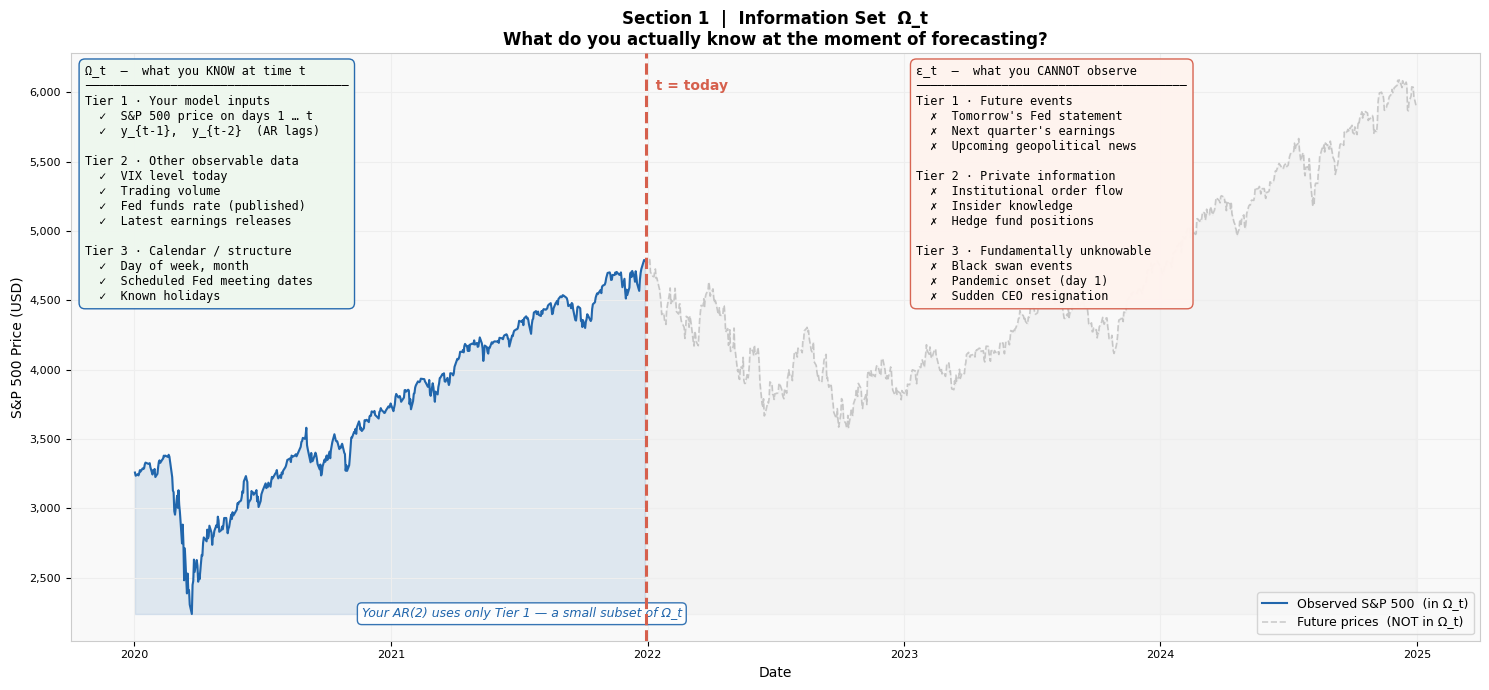

In [3]:
TODAY_IDX = 500                         # standing at trading day 500
today     = lag_df.index[TODAY_IDX]
print(f'Forecasting from: {today.date()}')

fig, ax = plt.subplots(figsize=(15, 7))

# ── known history ─────────────────────────────────────────────────────
known_px = sp500.iloc[:TODAY_IDX+2]
ax.fill_between(known_px.index, known_px, known_px.min(),
                alpha=0.12, color=C_ACT)
ax.plot(known_px.index, known_px, color=C_ACT, lw=1.5,
        label='Observed S&P 500  (in Ω_t)')

# ── unknown future ────────────────────────────────────────────────────
future_px = sp500.iloc[TODAY_IDX+2:]
ax.fill_between(future_px.index, future_px, known_px.min(),
                alpha=0.05, color=C_ERR)
ax.plot(future_px.index, future_px, color=C_ERR, lw=1.2,
        ls='--', alpha=0.4, label='Future prices  (NOT in Ω_t)')

# ── 'today' dividing line ─────────────────────────────────────────────
ax.axvline(today, color=C_FIT, lw=2.2, ls='--', zorder=5)
ax.text(today, ax.get_ylim()[1]*0.97, '  t = today',
        color=C_FIT, fontsize=10, fontweight='bold', va='top')

# ── what IS in Omega_t ────────────────────────────────────────────────
omega_txt = (
    'Ω_t  —  what you KNOW at time t\n'
    '─────────────────────────────────────\n'
    'Tier 1 · Your model inputs\n'
    '  ✓  S&P 500 price on days 1 … t\n'
    '  ✓  y_{t-1},  y_{t-2}  (AR lags)\n\n'
    'Tier 2 · Other observable data\n'
    '  ✓  VIX level today\n'
    '  ✓  Trading volume\n'
    '  ✓  Fed funds rate (published)\n'
    '  ✓  Latest earnings releases\n\n'
    'Tier 3 · Calendar / structure\n'
    '  ✓  Day of week, month\n'
    '  ✓  Scheduled Fed meeting dates\n'
    '  ✓  Known holidays'
)
ax.text(0.01, 0.98, omega_txt, transform=ax.transAxes,
        fontsize=8.5, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#EEF7EE',
                  edgecolor=C_ACT, alpha=0.97))

# ── what is NOT in Omega_t ────────────────────────────────────────────
unobs_txt = (
    'ε_t  —  what you CANNOT observe\n'
    '──────────────────────────────────────\n'
    'Tier 1 · Future events\n'
    '  ✗  Tomorrow\'s Fed statement\n'
    '  ✗  Next quarter\'s earnings\n'
    '  ✗  Upcoming geopolitical news\n\n'
    'Tier 2 · Private information\n'
    '  ✗  Institutional order flow\n'
    '  ✗  Insider knowledge\n'
    '  ✗  Hedge fund positions\n\n'
    'Tier 3 · Fundamentally unknowable\n'
    '  ✗  Black swan events\n'
    '  ✗  Pandemic onset (day 1)\n'
    '  ✗  Sudden CEO resignation'
)
ax.text(0.60, 0.98, unobs_txt, transform=ax.transAxes,
        fontsize=8.5, va='top', family='monospace',
        bbox=dict(boxstyle='round,pad=0.5', facecolor='#FFF3EE',
                  edgecolor=C_FIT, alpha=0.97))

# ── AR(2) scope note ──────────────────────────────────────────────────
ax.text(0.32, 0.04,
        'Your AR(2) uses only Tier 1 — a small subset of Ω_t',
        transform=ax.transAxes, fontsize=9, ha='center',
        style='italic', color=C_ACT,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=C_ACT, alpha=0.9))

ax.set_ylabel('S&P 500 Price (USD)')
ax.set_xlabel('Date')
ax.set_title(
    'Section 1  |  Information Set  Ω_t\n'
    'What do you actually know at the moment of forecasting?',
    fontweight='bold')
ax.legend(fontsize=9, loc='lower right')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


---
## Section 2 — What Falls into the Error Term?

ε_t is not random noise invented by statisticians.
**It is real — it has real causes.** We just do not have data on those causes.

There are three categories of things that end up in ε_t:

| Category | Description | Example | Can we fix it? |
|----------|-------------|---------|----------------|
| **Cat 1** | Information existed and was in Ω_t — but not in *your* model | Inflation data, VIX | **Yes** — add it as a predictor |
| **Cat 2** | Information existed but nobody had it at time t | Pandemic on day 1 | No (at the time) |
| **Cat 3** | Fundamentally unforecastable | Random geopolitical shock | Never |

> **Key implication:** A large ε_t does not automatically mean a bad model.
> It might mean an extraordinary event occurred.
> Conversely, a small ε_t might mean Cat 1 problems — your model is leaving
> usable information on the table.


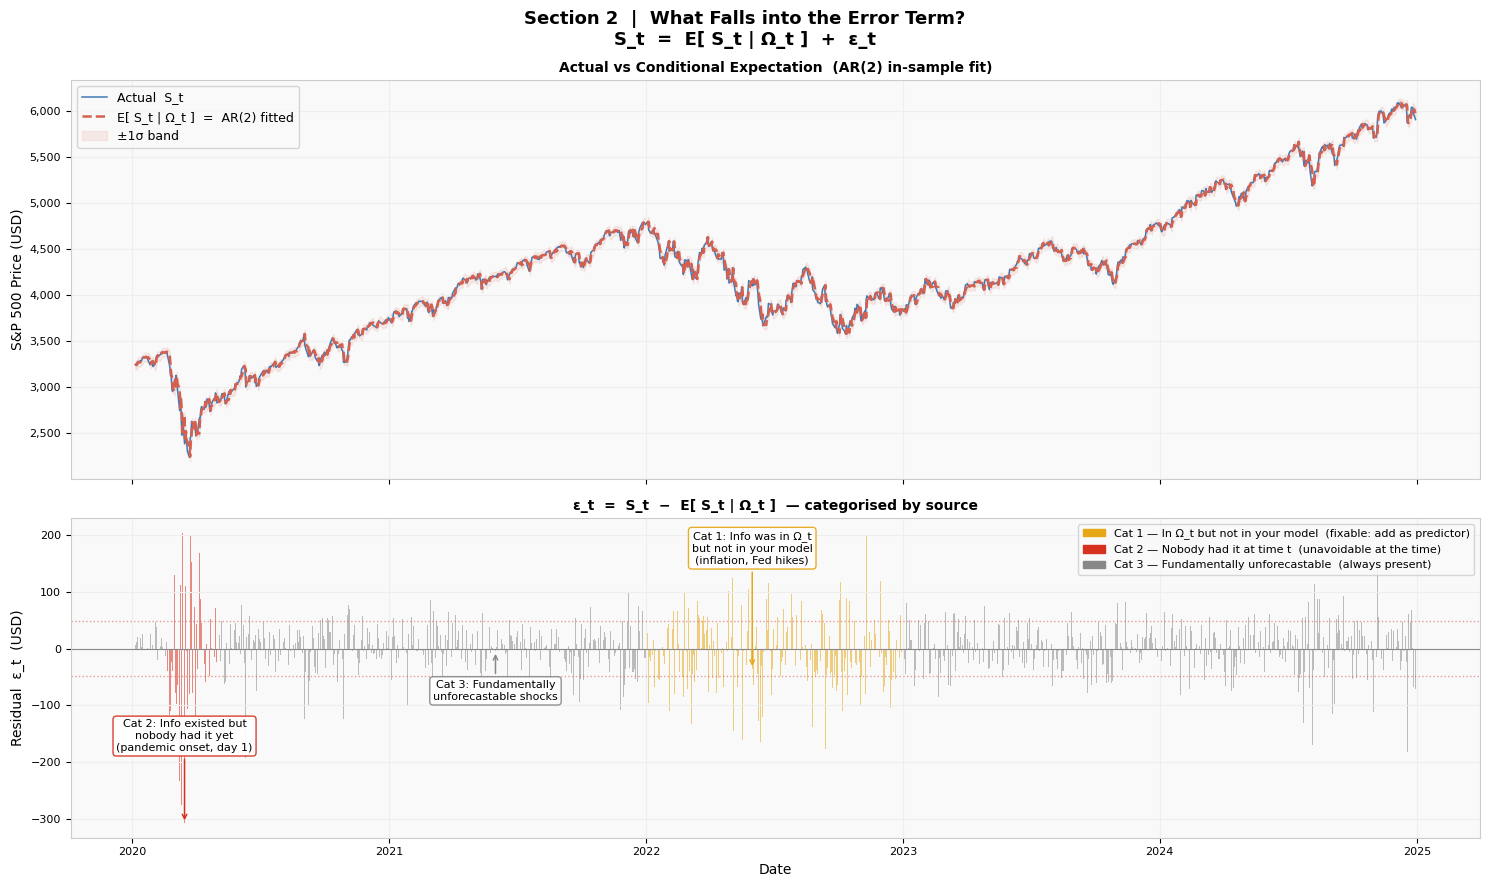

In [4]:
fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                         gridspec_kw={'height_ratios': [2.5, 2]})
fig.suptitle(
    'Section 2  |  What Falls into the Error Term?\n'
    'S_t  =  E[ S_t | Ω_t ]  +  ε_t',
    fontweight='bold', fontsize=13)

# ── top panel: actual vs conditional expectation ──────────────────────
ax = axes[0]
ax.plot(lag_df.index, y, color=C_ACT, lw=1.1, alpha=0.85,
        label='Actual  S_t')
ax.plot(lag_df.index, fitted, color=C_FIT, lw=1.8, ls='--',
        label='E[ S_t | Ω_t ]  =  AR(2) fitted')
ax.fill_between(lag_df.index, fitted-sigma, fitted+sigma,
                alpha=0.10, color=C_FIT, label='±1σ band')
ax.set_ylabel('S&P 500 Price (USD)')
ax.set_title('Actual vs Conditional Expectation  (AR(2) in-sample fit)',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=9)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# ── bottom panel: residuals coloured by category ──────────────────────
ax = axes[1]

cat_colors = []
for d, r in zip(lag_df.index, resid):
    if pd.Timestamp('2020-02-20') <= d <= pd.Timestamp('2020-04-30'):
        cat_colors.append(C_DOWN)   # Cat 2: nobody had it
    elif pd.Timestamp('2022-01-01') <= d <= pd.Timestamp('2022-12-31'):
        cat_colors.append(C_GOLD)   # Cat 1: info existed, not in model
    else:
        cat_colors.append(C_ERR)    # Cat 3: unforecastable

ax.bar(lag_df.index, resid, color=cat_colors, alpha=0.55, width=1.0)
ax.axhline(0,       color=C_ERR, lw=0.8)
ax.axhline( sigma,  color=C_FIT, lw=1.0, ls=':', alpha=0.6)
ax.axhline(-sigma,  color=C_FIT, lw=1.0, ls=':', alpha=0.6)

# annotate each category
annots = [
    ('2020-03-16', -180,
     'Cat 2: Info existed but\nnobody had it yet\n(pandemic onset, day 1)',
     C_DOWN),
    ('2022-06-01',  150,
     'Cat 1: Info was in Ω_t\nbut not in your model\n(inflation, Fed hikes)',
     C_GOLD),
    ('2021-06-01', -90,
     'Cat 3: Fundamentally\nunforecastable shocks',
     C_ERR),
]
for ds, y_ann, lbl, col in annots:
    xv = pd.Timestamp(ds)
    xi = lag_df.index.searchsorted(xv)
    xi = min(xi, len(resid)-1)
    ax.annotate(lbl,
                xy=(lag_df.index[xi], resid[xi]),
                xytext=(xv, y_ann),
                arrowprops=dict(arrowstyle='->', color=col, lw=1.1),
                fontsize=8, ha='center', color='black',
                bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                          edgecolor=col, alpha=0.92))

p1 = mpatches.Patch(color=C_GOLD,
     label='Cat 1 — In Ω_t but not in your model  (fixable: add as predictor)')
p2 = mpatches.Patch(color=C_DOWN,
     label='Cat 2 — Nobody had it at time t  (unavoidable at the time)')
p3 = mpatches.Patch(color=C_ERR,
     label='Cat 3 — Fundamentally unforecastable  (always present)')
ax.legend(handles=[p1,p2,p3], fontsize=8, loc='upper right')
ax.set_ylabel('Residual  ε_t  (USD)')
ax.set_xlabel('Date')
ax.set_title('ε_t  =  S_t  −  E[ S_t | Ω_t ]  — categorised by source',
             fontsize=10, fontweight='bold')
plt.tight_layout()
plt.show()


---
## Section 3 — Conditional Expectation  E[ S_t | Ω_t ]

**Definition:**
> E[ S_t | Ω_t ] is the mean of the distribution of S_t,
> given everything in Ω_t.

This is what your model produces — not S_t itself,
but your best estimate of S_t before it is realised.

Two things follow directly:

- **The forecast is a distribution, not a point.**
  The ±σ band shows the range of typical outcomes around the expectation.
- **ε_t measures the distance from the centre of that distribution.**
  A large |ε_t| means an unusual event occurred —
  something outside Ω_t moved the market more than expected.


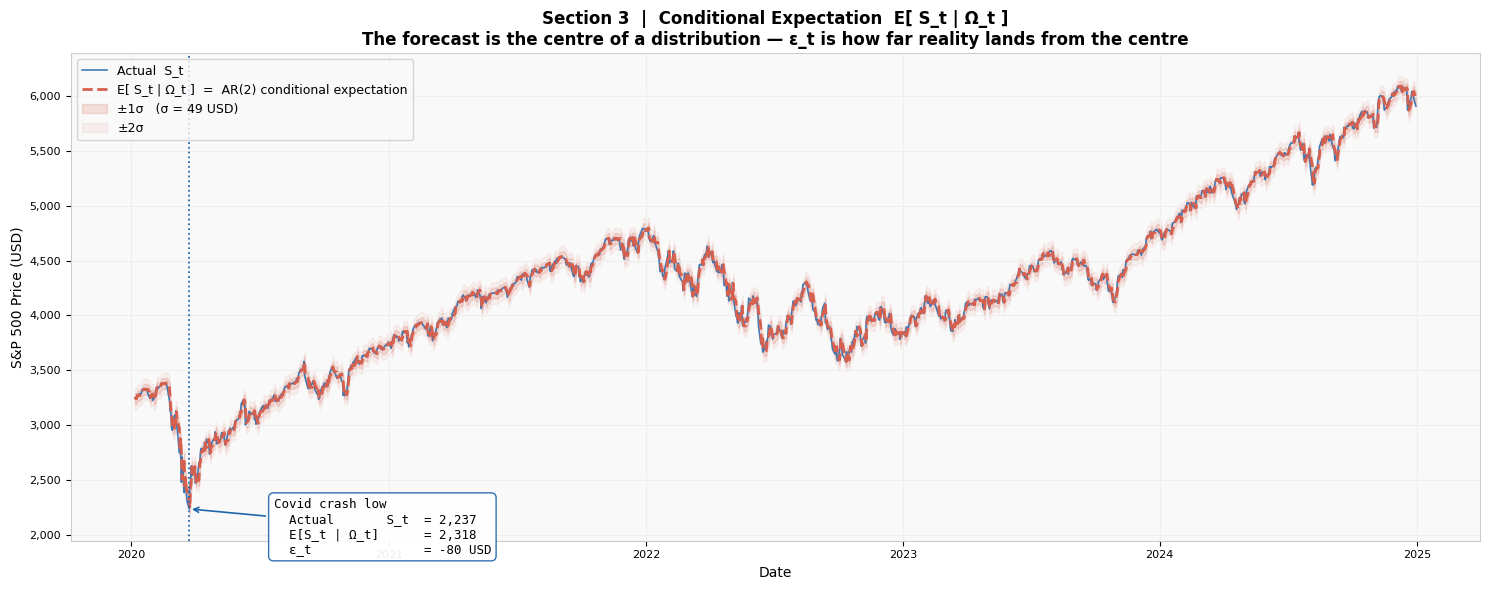

In [5]:
fig, ax = plt.subplots(figsize=(15, 6))

ax.plot(lag_df.index, y,
        color=C_ACT, lw=1.2, alpha=0.85,
        label='Actual  S_t')
ax.plot(lag_df.index, fitted,
        color=C_FIT, lw=2.0, ls='--',
        label='E[ S_t | Ω_t ]  =  AR(2) conditional expectation')
ax.fill_between(lag_df.index, fitted-sigma,   fitted+sigma,
                alpha=0.18, color=C_FIT,
                label=f'±1σ   (σ = {sigma:.0f} USD)')
ax.fill_between(lag_df.index, fitted-2*sigma, fitted+2*sigma,
                alpha=0.07, color=C_FIT, label='±2σ')

# annotate the Covid crash low — largest single ε_t
crash_idx  = np.argmin(y[:200])
crash_date = lag_df.index[crash_idx]
ax.axvline(crash_date, color=C_ACT, lw=1.3, ls=':')
ax.annotate(
    f'Covid crash low\n'
    f'  Actual       S_t  = {y[crash_idx]:,.0f}\n'
    f'  E[S_t | Ω_t]      = {fitted[crash_idx]:,.0f}\n'
    f'  ε_t               = {resid[crash_idx]:+,.0f} USD',
    xy=(crash_date, y[crash_idx]),
    xytext=(crash_date + pd.Timedelta(days=120), y[crash_idx]-400),
    arrowprops=dict(arrowstyle='->', color=C_ACT, lw=1.2),
    fontsize=9, color='black', family='monospace',
    bbox=dict(boxstyle='round,pad=0.4', facecolor='white',
              edgecolor=C_ACT, alpha=0.93))

ax.set_ylabel('S&P 500 Price (USD)')
ax.set_xlabel('Date')
ax.set_title(
    'Section 3  |  Conditional Expectation  E[ S_t | Ω_t ]\n'
    'The forecast is the centre of a distribution — ε_t is how far reality lands from the centre',
    fontweight='bold')
ax.legend(fontsize=9, loc='upper left')
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
plt.tight_layout()
plt.show()


---
## Section 4 — Decomposition of Monthly Price Changes

Each month's price change can be split into two parts:

&emsp; **ΔS_t** &nbsp; = &nbsp; **E[ ΔS_t | Ω_t ]** &nbsp; + &nbsp; **ε_t**

The stacked bar chart below makes this concrete:
- The **orange bar** is what the model predicted
- The **coloured portion on top** is ε_t — the part the model missed

> **What to look for:**
> On calm months, the orange bar explains most of the move.
> During regime shifts (Covid, 2022 rate hikes), the ε_t bar dominates.
> This is not a coincidence — regime shifts are precisely the moments
> when something outside Ω_t entered the world.

> **The cliffhanger:**
> Look carefully at the ε_t bars. They are not entirely random.
> During 2022 they are persistently negative — month after month.
> That pattern suggests ε_t may contain **systematic structure**
> — cycles, seasonality, or regime components — not pure noise.
> That is exactly what we study next.


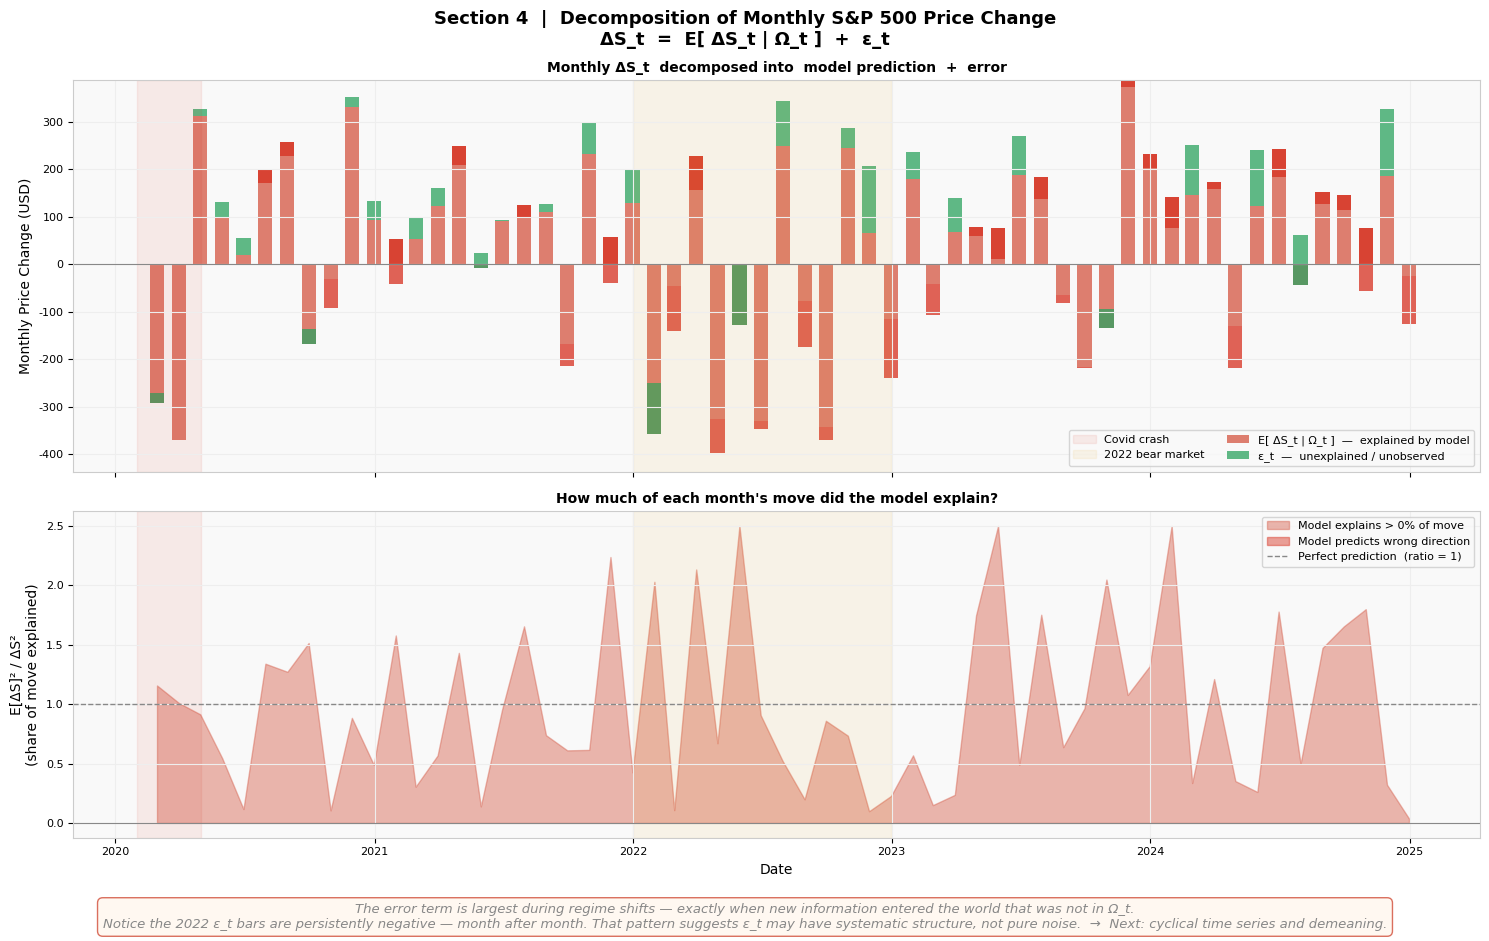

In [6]:
# ── aggregate to monthly ─────────────────────────────────────────────
monthly  = lag_df.resample('ME').last()
mfitted  = reg.predict(monthly[['yt_1','yt_2']].values)
mresid   = monthly['yt'].values - mfitted

m_actual_chg = np.diff(monthly['yt'].values)
m_fitted_chg = np.diff(mfitted)
m_resid_chg  = np.diff(mresid)
m_dates      = monthly.index[1:]

fig, axes = plt.subplots(2, 1, figsize=(15, 9), sharex=True,
                         gridspec_kw={'height_ratios': [1.2, 1]})
fig.suptitle(
    'Section 4  |  Decomposition of Monthly S&P 500 Price Change\n'
    'ΔS_t  =  E[ ΔS_t | Ω_t ]  +  ε_t',
    fontweight='bold', fontsize=13)

# ── top: stacked bar — model prediction + error ───────────────────────
ax = axes[0]
bar_w = 20
ax.bar(m_dates, m_fitted_chg, width=bar_w,
       color=C_FIT, alpha=0.80,
       label='E[ ΔS_t | Ω_t ]  —  explained by model')
err_colors = [C_DOWN if e < 0 else C_UP for e in m_resid_chg]
ax.bar(m_dates, m_resid_chg, width=bar_w, bottom=m_fitted_chg,
       color=err_colors, alpha=0.75,
       label='ε_t  —  unexplained / unobserved')
ax.axhline(0, color=C_ERR, lw=0.8)
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'),
           alpha=0.08, color=C_DOWN, label='Covid crash')
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.08, color=C_GOLD, label='2022 bear market')
ax.set_ylabel('Monthly Price Change (USD)')
ax.set_title('Monthly ΔS_t  decomposed into  model prediction  +  error',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, loc='lower right', ncol=2)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# ── bottom: share of variance explained ──────────────────────────────
ax = axes[1]
total_var  = m_actual_chg**2
model_var  = m_fitted_chg**2
ratio      = np.where(total_var > 0, model_var/total_var, 0)
ratio      = np.clip(ratio, -0.5, 2.5)

ax.fill_between(m_dates, ratio, 0,
                where=ratio>=0, color=C_FIT, alpha=0.45,
                label='Model explains > 0% of move')
ax.fill_between(m_dates, ratio, 0,
                where=ratio<0,  color=C_DOWN, alpha=0.45,
                label='Model predicts wrong direction')
ax.axhline(1, color=C_ERR, lw=1.0, ls='--',
           label='Perfect prediction  (ratio = 1)')
ax.axhline(0, color=C_ERR, lw=0.8)
ax.axvspan(pd.Timestamp('2020-02-01'), pd.Timestamp('2020-05-01'),
           alpha=0.08, color=C_DOWN)
ax.axvspan(pd.Timestamp('2022-01-01'), pd.Timestamp('2022-12-31'),
           alpha=0.08, color=C_GOLD)
ax.set_ylabel('E[ΔS]² / ΔS²\n(share of move explained)')
ax.set_xlabel('Date')
ax.set_title('How much of each month\'s move did the model explain?',
             fontsize=10, fontweight='bold')
ax.legend(fontsize=8, loc='upper right')

note = (
    'The error term is largest during regime shifts — exactly when new information '
    'entered the world that was not in Ω_t.\n'
    'Notice the 2022 ε_t bars are persistently negative — month after month. '
    'That pattern suggests ε_t may have systematic structure, '
    'not pure noise.  →  Next: cyclical time series and demeaning.'
)
fig.text(0.5, -0.04, note, ha='center', fontsize=9.5,
         style='italic', color=C_ERR,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#FFF8F0',
                   edgecolor=C_FIT, alpha=0.9))
plt.tight_layout()
plt.show()


---
## Summary


---
## Section 5 — From Price Level to Log Return

Before demeaning, we need to ask: **should we even run AR on the price level?**

The answer is no — for two reasons:

**Reason 1 — Non-stationarity.**
The S&P 500 price has a strong upward trend.
An AR model fit on price levels learns one thing: *tomorrow's price ≈ today's price.*
The high R² you saw in Section 4 is not real predictive power —
it is just the model capturing the fact that prices do not jump to zero overnight.

**Reason 2 — Comparability across time.**
A move of 100 USD when the index is at 2,000 is very different from
a move of 100 USD when the index is at 5,000.
Log returns express moves as *proportional changes*, making every period comparable.

> **A note on deflation.**
> In macroeconomics, you would additionally divide by the CPI price index
> to convert nominal prices into *real* prices, removing the effect of inflation.
> For daily stock returns over a 5-year window, this adjustment is small
> relative to market volatility, so we focus on the statistical transformation here.

The log return is defined as:

&emsp; r_t  =  log( S_t / S_{t-1} )  =  log(S_t) − log(S_{t-1})

For small daily moves this is approximately equal to the simple percentage return,
but it is additive across time and better behaved statistically.


In [7]:
# ── compute log returns ─────────────────────────────────────────────
log_ret  = np.log(sp500 / sp500.shift(1)).dropna()

print(f'Price level range : {sp500.min():,.0f}  →  {sp500.max():,.0f} USD')
print(f'Log return mean   : {log_ret.mean():.6f}  ({log_ret.mean()*100:.4f}% per day)')
print(f'Log return std    : {log_ret.std():.6f}  ({log_ret.std()*100:.4f}% per day)')
print(f'Log return min    : {log_ret.min():.6f}   max: {log_ret.max():.6f}')


Price level range : 2,237  →  6,090 USD
Log return mean   : 0.000474  (0.0474% per day)
Log return std    : 0.013504  (1.3504% per day)
Log return min    : -0.127652   max: 0.089683


##### Plot 5 — Price level vs log return: time series and distributions


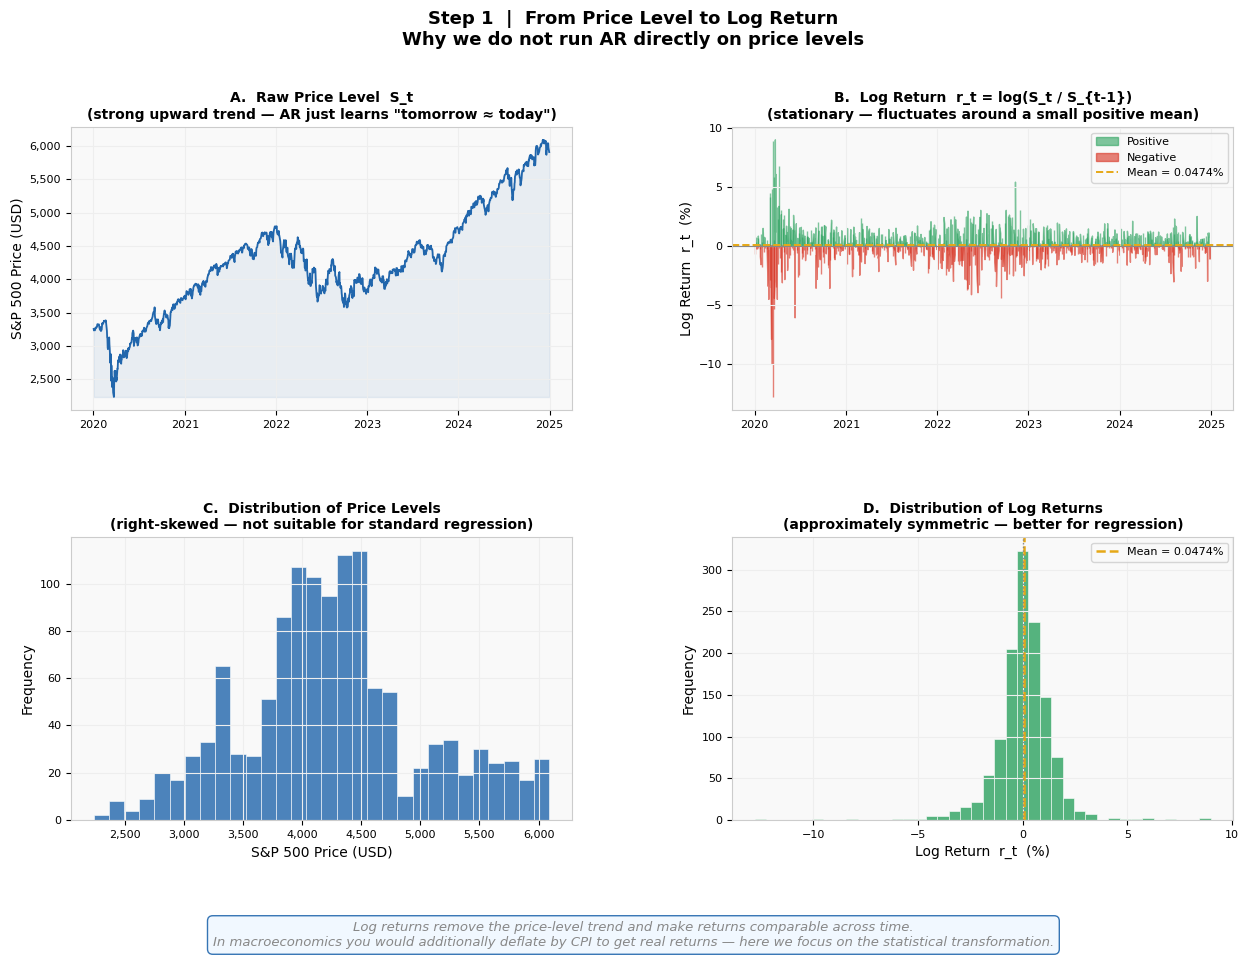

In [8]:
fig = plt.figure(figsize=(15, 9))
gs  = gridspec.GridSpec(2, 2, figure=fig, hspace=0.45, wspace=0.32)
fig.suptitle(
    'Step 1  |  From Price Level to Log Return\n'
    'Why we do not run AR directly on price levels',
    fontsize=13, fontweight='bold', y=1.01)

# ── A: raw price level ────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 0])
ax.plot(sp500.index, sp500, color=C_ACT, lw=1.3)
ax.fill_between(sp500.index, sp500, sp500.min(), alpha=0.08, color=C_ACT)
ax.set_ylabel('S&P 500 Price (USD)')
ax.set_title('A.  Raw Price Level  S_t\n'
             '(strong upward trend — AR just learns "tomorrow ≈ today")',
             fontweight='bold', fontsize=10)
ax.yaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# ── B: log return ─────────────────────────────────────────────────────
ax = fig.add_subplot(gs[0, 1])
ax.fill_between(log_ret.index, log_ret*100, 0,
                where=log_ret>=0, color=C_UP,   alpha=0.60, label='Positive')
ax.fill_between(log_ret.index, log_ret*100, 0,
                where=log_ret<0,  color=C_DOWN, alpha=0.60, label='Negative')
ax.axhline(0,                color=C_ERR,  lw=0.8)
ax.axhline(log_ret.mean()*100, color=C_GOLD, lw=1.4, ls='--',
           label=f'Mean = {log_ret.mean()*100:.4f}%')
ax.set_ylabel('Log Return  r_t  (%)')
ax.set_title('B.  Log Return  r_t = log(S_t / S_{t-1})\n'
             '(stationary — fluctuates around a small positive mean)',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

# ── C: price histogram ────────────────────────────────────────────────
ax = fig.add_subplot(gs[1, 0])
ax.hist(sp500.values, bins=30, color=C_ACT,
        edgecolor='white', linewidth=0.5, alpha=0.8)
ax.set_xlabel('S&P 500 Price (USD)')
ax.set_ylabel('Frequency')
ax.set_title('C.  Distribution of Price Levels\n'
             '(right-skewed — not suitable for standard regression)',
             fontweight='bold', fontsize=10)
ax.xaxis.set_major_formatter(mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))

# ── D: log return histogram ───────────────────────────────────────────
ax = fig.add_subplot(gs[1, 1])
ax.hist(log_ret.values*100, bins=40, color=C_UP,
        edgecolor='white', linewidth=0.5, alpha=0.8)
ax.axvline(log_ret.mean()*100, color=C_GOLD, lw=1.8, ls='--',
           label=f'Mean = {log_ret.mean()*100:.4f}%')
ax.axvline(0, color=C_ERR, lw=1.0, ls=':')
ax.set_xlabel('Log Return  r_t  (%)')
ax.set_ylabel('Frequency')
ax.set_title('D.  Distribution of Log Returns\n'
             '(approximately symmetric — better for regression)',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=8)

note = (
    'Log returns remove the price-level trend and make returns comparable across time.\n'
    'In macroeconomics you would additionally deflate by CPI to get real returns — '
    'here we focus on the statistical transformation.'
)
fig.text(0.5, -0.03, note, ha='center', fontsize=9.5, style='italic', color=C_ERR,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F8FF',
                   edgecolor=C_ACT, alpha=0.9))
plt.show()


---
## Section 6 — Demeaning the Log Return

The log return r_t has a small but non-zero mean: the market drifts upward
on average over time.

When we run AR without demeaning, the intercept β₀ absorbs this mean.
That is not wrong, but it is inefficient: the intercept is using up a
degree of freedom just to estimate something we could subtract out directly.

**Demeaning** removes this constant drift before modelling the dynamics:

&emsp; r̃_t  =  r_t  −  r̄

where r̄ is the sample mean of r_t.
After demeaning, the series oscillates around exactly zero.
The AR model then needs no intercept — it focuses entirely on the
autocorrelation structure.

> **Key property:** demeaning only shifts the location.
> The standard deviation, autocorrelations, and all higher-order
> dynamics are identical in r_t and r̃_t.


In [9]:
# ── demean the log return ────────────────────────────────────────────
ret_mean = log_ret.mean()
dm_ret   = log_ret - ret_mean

print(f'log_ret mean : {ret_mean:.8f}  ({ret_mean*100:.6f}% per day)')
print(f'dm_ret  mean : {dm_ret.mean():.2e}  (effectively zero)')
print(f'log_ret std  : {log_ret.std():.8f}')
print(f'dm_ret  std  : {dm_ret.std():.8f}  (unchanged — only location shifts)')


log_ret mean : 0.00047377  (0.047377% per day)
dm_ret  mean : -1.77e-19  (effectively zero)
log_ret std  : 0.01350437
dm_ret  std  : 0.01350437  (unchanged — only location shifts)


##### Plot 6 — Before and after demeaning


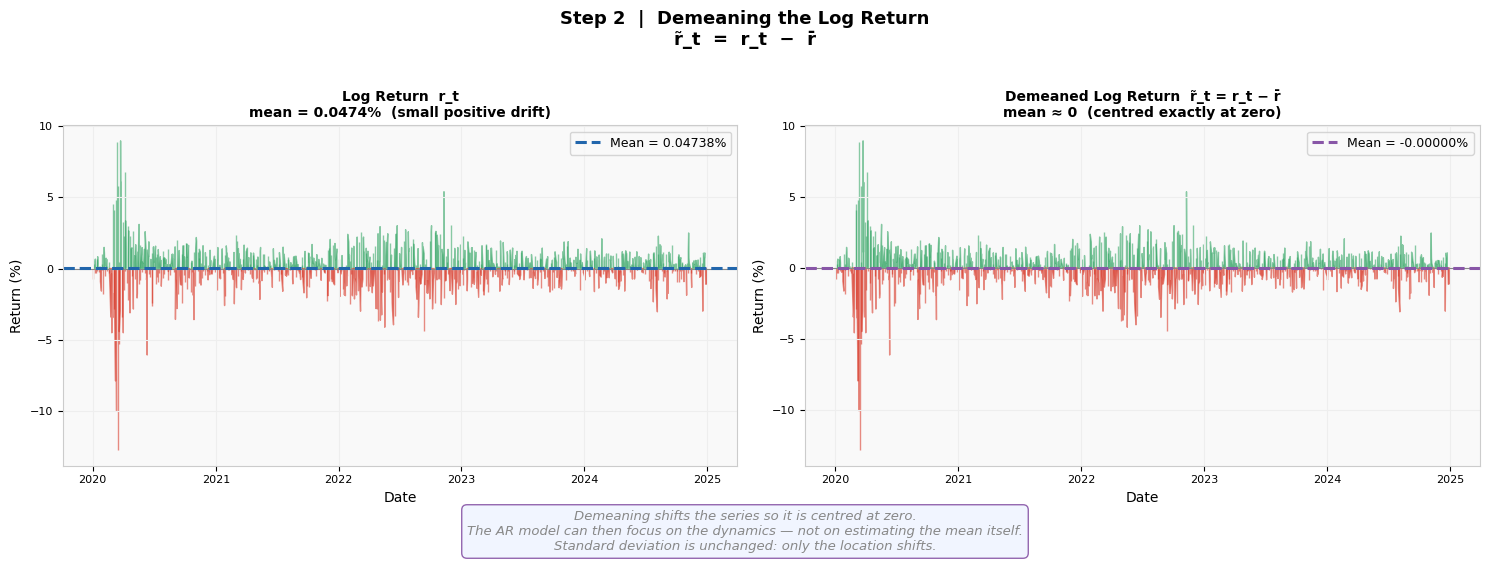

In [15]:
# Define purple color for demeaned series
C_PURP = '#8856a7'

fig, axes = plt.subplots(1, 2, figsize=(15, 5))
fig.suptitle(
    'Step 2  |  Demeaning the Log Return\n'
    'r̃_t  =  r_t  −  r̄',
    fontsize=13, fontweight='bold', y=1.02)

series_list = [
    (log_ret*100, C_ACT,
     f'Log Return  r_t\nmean = {log_ret.mean()*100:.4f}%  (small positive drift)'),
    (dm_ret*100,  C_PURP,
     f'Demeaned Log Return  r̃_t = r_t − r̄\nmean ≈ 0  (centred exactly at zero)'),
]

for ax, (series, color, title) in zip(axes, series_list):
    ax.fill_between(series.index, series, 0,
                    where=series>=0, color=C_UP,   alpha=0.55)
    ax.fill_between(series.index, series, 0,
                    where=series<0,  color=C_DOWN, alpha=0.55)
    ax.axhline(0,             color=C_ERR,  lw=0.8)
    ax.axhline(series.mean(), color=color,  lw=2.2, ls='--',
               label=f'Mean = {series.mean():.5f}%')
    ax.set_ylabel('Return (%)')
    ax.set_xlabel('Date')
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.legend(fontsize=9)

note = (
    'Demeaning shifts the series so it is centred at zero.\n'
    'The AR model can then focus on the dynamics — not on estimating the mean itself.\n'
    'Standard deviation is unchanged: only the location shifts.'
)
fig.text(0.5, -0.06, note, ha='center', fontsize=9.5, style='italic', color=C_ERR,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F0F4FF',
                   edgecolor=C_PURP, alpha=0.9))
plt.tight_layout()
plt.show()


---
## Section 7 — AR(2) on Demeaned Log Returns

Now we rerun the AR(2) on r̃_t instead of on the price level.

The model becomes:

&emsp; r̃_t  =  β₁ · r̃_{t-1}  +  β₂ · r̃_{t-2}  +  ε_t

Note: **no intercept is needed** — the mean was already removed.
If we included an intercept it would be estimated as approximately zero anyway.

We first look at the scatter plot (as always, before fitting),
then add the regression line.


In [ ]:
# ── build lag dataset on demeaned returns ────────────────────────────
dm_df = pd.DataFrame({
    'yt':   dm_ret,
    'yt_1': dm_ret.shift(1),
    'yt_2': dm_ret.shift(2),
}).dropna()

X_dm     = dm_df[['yt_1','yt_2']].values
y_dm     = dm_df['yt'].values
reg_dm   = LinearRegression(fit_intercept=False).fit(X_dm, y_dm)
fit_dm   = reg_dm.predict(X_dm)
resid_dm = y_dm - fit_dm
r2_dm    = reg_dm.score(X_dm, y_dm)

print('AR(2) on demeaned log returns  (no intercept)')
print(f'  β₁ = {reg_dm.coef_[0]:.6f}   (on r̃_{{t-1}})')
print(f'  β₂ = {reg_dm.coef_[1]:.6f}   (on r̃_{{t-2}})')
print(f'  R² = {r2_dm:.6f}')
print(f'  σ_ε = {resid_dm.std()*100:.6f}%')


##### Plot 7 — AR(2) on demeaned returns: scatter + fitted line


In [ ]:
# simple AR(1) for the scatter line
lag1_dm  = dm_df['yt_1'].values
reg_dm1  = LinearRegression(fit_intercept=False).fit(lag1_dm.reshape(-1,1), y_dm)
r2_dm1   = reg_dm1.score(lag1_dm.reshape(-1,1), y_dm)
x_line   = np.linspace(lag1_dm.min(), lag1_dm.max(), 200).reshape(-1,1)

fig, axes = plt.subplots(1, 2, figsize=(14, 6))
fig.suptitle(
    'Step 3  |  AR(2) on Demeaned Log Returns\n'
    'r̃_t  =  β₁ · r̃_{t-1}  +  β₂ · r̃_{t-2}  +  ε_t   (no intercept)',
    fontsize=12, fontweight='bold', y=1.02)

# ── A: scatter r̃_{t-1} vs r̃_t ───────────────────────────────────────
ax = axes[0]
ax.scatter(lag1_dm*100, y_dm*100,
           alpha=0.18, s=12, color=C_PURP, edgecolors='none',
           label='Observed')
ax.plot(x_line*100, reg_dm1.predict(x_line)*100,
        color=C_FIT, lw=2.2,
        label=f'AR(1) fit   β₁ = {reg_dm1.coef_[0]:.4f}')
ax.axhline(0, color=C_ERR, lw=0.8, ls='--')
ax.axvline(0, color=C_ERR, lw=0.8, ls='--')
ax.set_xlabel('r̃_{t-1}  (%)')
ax.set_ylabel('r̃_t  (%)')
ax.set_title('A.  Scatter: r̃_{t-1}  vs  r̃_t\n'
             'Both axes centred at zero after demeaning',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=9)
note_l = (
    f'R² ≈ {r2_dm1:.5f}\n'
    'Near-zero: past returns barely\n'
    'predict future returns.\n'
    'Consistent with market efficiency.'
)
ax.text(0.03, 0.97, note_l, transform=ax.transAxes, fontsize=8.5,
        va='top', style='italic', color=C_ERR,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=C_PURP, alpha=0.88))

# ── B: actual vs fitted ───────────────────────────────────────────────
ax = axes[1]
ax.plot(dm_df.index, y_dm*100,   color=C_PURP, lw=0.9, alpha=0.7,
        label='Actual  r̃_t')
ax.plot(dm_df.index, fit_dm*100, color=C_FIT,  lw=1.6, ls='--',
        label=f'AR(2) fitted   R² = {r2_dm:.5f}')
ax.axhline(0, color=C_ERR, lw=0.8)
ax.set_ylabel('Demeaned Log Return  r̃_t  (%)')
ax.set_xlabel('Date')
ax.set_title('B.  AR(2) Fitted vs Actual  (in-sample)',
             fontweight='bold', fontsize=10)
ax.legend(fontsize=9)
note_r = (
    f'β₁ = {reg_dm.coef_[0]:.5f}\n'
    f'β₂ = {reg_dm.coef_[1]:.5f}\n'
    'Small coefficients: weak serial\n'
    'correlation in daily returns.\n'
    'Expected for liquid equity markets.'
)
ax.text(0.03, 0.97, note_r, transform=ax.transAxes, fontsize=8.5,
        va='top', family='monospace', color=C_ERR,
        bbox=dict(boxstyle='round,pad=0.35', facecolor='white',
                  edgecolor=C_FIT, alpha=0.88))
plt.tight_layout()
plt.show()


---
## Section 8 — Three Models Side by Side

We now compare all three AR(2) specifications on the same data:

| Model | Input | Intercept | R² expected |
|-------|-------|-----------|-------------|
| 1 | Raw price level  S_t | Yes | Very high (spurious) |
| 2 | Log return  r_t | Yes | Near zero |
| 3 | Demeaned log return  r̃_t | **No** | Near zero, cleanest residuals |

The key lesson: **Model 1's high R² is misleading.**
It does not mean the model is good at forecasting —
it means the price level is non-stationary and the AR is
exploiting that structure rather than genuine predictability.
Models 2 and 3 tell the honest story.


In [ ]:
# ── Model 1: AR(2) on raw price level ───────────────────────────────
lag_raw   = pd.DataFrame({
    'yt':  sp500, 'yt_1': sp500.shift(1), 'yt_2': sp500.shift(2)
}).dropna()
X_raw     = lag_raw[['yt_1','yt_2']].values
y_raw     = lag_raw['yt'].values
reg_raw   = LinearRegression().fit(X_raw, y_raw)
fit_raw   = reg_raw.predict(X_raw)
res_raw   = y_raw - fit_raw

# ── Model 2: AR(2) on log returns ────────────────────────────────────
lr_df     = pd.DataFrame({
    'yt':  log_ret, 'yt_1': log_ret.shift(1), 'yt_2': log_ret.shift(2)
}).dropna()
X_lr      = lr_df[['yt_1','yt_2']].values
y_lr      = lr_df['yt'].values
reg_lr    = LinearRegression().fit(X_lr, y_lr)
fit_lr    = reg_lr.predict(X_lr)
res_lr    = y_lr - fit_lr

# ── Model 3: already fitted above ────────────────────────────────────

models = [
    ('Model 1\nAR(2) on Price Level S_t',
     lag_raw.index, y_raw,      fit_raw,    res_raw,
     reg_raw.score(X_raw,y_raw), C_ACT,   'USD'),
    ('Model 2\nAR(2) on Log Return r_t',
     lr_df.index,  y_lr*100,   fit_lr*100, res_lr*100,
     reg_lr.score(X_lr,y_lr),   C_UP,    '%'),
    ('Model 3\nAR(2) on Demeaned r̃_t',
     dm_df.index,  y_dm*100,   fit_dm*100, resid_dm*100,
     r2_dm,                     C_PURP,  '%'),
]

fig, axes = plt.subplots(2, 3, figsize=(20, 9),
                         gridspec_kw={'height_ratios': [2.5, 1.2]})
fig.suptitle(
    'Step 4  |  Three Models Side by Side\n'
    'How does the choice of input transformation affect the AR(2)?',
    fontsize=13, fontweight='bold', y=1.01)

for col, (title, idx, yact, yfit, yres, r2, color, unit) in enumerate(models):
    # ── top row: actual vs fitted ──────────────────────────────────
    ax = axes[0, col]
    ax.plot(idx, yact, color=color, lw=0.9, alpha=0.75, label='Actual')
    ax.plot(idx, yfit, color=C_FIT,  lw=1.6, ls='--',
            label=f'Fitted  (R²={r2:.4f})')
    ax.axhline(0, color=C_ERR, lw=0.7)
    ax.set_title(title, fontweight='bold', fontsize=10)
    ax.set_ylabel(f'Value ({unit})')
    ax.legend(fontsize=8)
    if unit == 'USD':
        ax.yaxis.set_major_formatter(
            mticker.FuncFormatter(lambda x,_: f'{x:,.0f}'))
    ax.text(0.03, 0.05, f'R² = {r2:.6f}',
            transform=ax.transAxes, fontsize=9, va='bottom',
            family='monospace',
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=color, alpha=0.88))

    # ── bottom row: residuals ──────────────────────────────────────
    ax = axes[1, col]
    yres_arr = np.array(yres)
    ax.fill_between(idx, yres_arr, 0,
                    where=yres_arr>=0, color=C_UP,   alpha=0.55)
    ax.fill_between(idx, yres_arr, 0,
                    where=yres_arr<0,  color=C_DOWN, alpha=0.55)
    ax.axhline(0, color=C_ERR, lw=0.8)
    ax.set_ylabel(f'Residual ({unit})')
    ax.set_xlabel('Date')
    ax.text(0.03, 0.97, f'σ_ε = {np.std(yres_arr):.4f} {unit}',
            transform=ax.transAxes, fontsize=8.5, va='top',
            family='monospace', color=C_ERR,
            bbox=dict(boxstyle='round,pad=0.3', facecolor='white',
                      edgecolor=C_ERR, alpha=0.85))

note = (
    'Model 1 R² is very high — but this is spurious: the AR is just learning '
    '"tomorrow\'s price ≈ today\'s price" from a non-stationary series.\n'
    'Models 2 and 3 show the honest picture: R² near zero, '
    'consistent with market efficiency.\n'
    'Model 3 residuals are centred at zero with no visible drift — '
    'the cleanest foundation for further modelling.'
)
fig.text(0.5, -0.04, note, ha='center', fontsize=9.5, style='italic', color=C_ERR,
         bbox=dict(boxstyle='round,pad=0.4', facecolor='#F8F4FF',
                   edgecolor=C_PURP, alpha=0.9))
plt.tight_layout()
plt.show()


In [ ]:
print('=' * 62)
print('INFORMATION SET, CONDITIONAL EXPECTATION & ERROR TERM')
print('=' * 62)
print()
print('  S_t  =  E[ S_t | Ω_t ]  +  ε_t')
print()
rows = [
    ('Ω_t',
     'Information set',
     'Everything observable up to time t.',
     'Past prices, VIX, volume, calendar, published rates.'),
    ('E[S_t|Ω_t]',
     'Conditional expectation',
     'Best forecast given Ω_t.  Centre of forecast distribution.',
     'The AR(2) fitted value.'),
    ('ε_t  Cat 1',
     'In Ω_t, not in model',
     'Fixable — add the variable as a predictor.',
     '2022 inflation / Fed hike signal.'),
    ('ε_t  Cat 2',
     'Nobody had it at time t',
     'Unavoidable at the time.',
     'Covid pandemic onset.'),
    ('ε_t  Cat 3',
     'Fundamentally unforecastable',
     'Always present — sets the floor on forecast error.',
     'Random geopolitical shocks.'),
]
for symbol, name, definition, example in rows:
    print(f'  {symbol}')
    print(f'    Name       : {name}')
    print(f'    Definition : {definition}')
    print(f'    Example    : {example}')
    print()
print('-' * 62)
print('TRANSFORMATIONS')
print('-' * 62)
print()
print('  Step 1 — Log return:  r_t = log(S_t / S_{t-1})')
print('           Removes price-level trend; makes periods comparable.')
print('           (In macro: also deflate by CPI for real prices.)')
print()
print('  Step 2 — Demean:      r̃_t = r_t − r̄')
print('           Centres series at zero; AR needs no intercept.')
print('           Std deviation unchanged — only location shifts.')
print()
print('  Step 3 — AR(2) on r̃_t:')
print('           r̃_t = β₁·r̃_{t-1} + β₂·r̃_{t-2} + ε_t')
print('           Honest R² ≈ 0 — reflects true market predictability.')
print()
print('─' * 62)
print('Coming next: the ε_t still has structure — cyclical components.')
print('To model them properly we study demeaning and deseasonalisation.')
